# QUESTION 1

## Importing the necessary libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import log_loss
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
import matplotlib.pyplot as plt

## 1.1. Data Preparation

a) Import the Abalone dataset from the UCI Machine Learning Repository, which contains 4,177 observations and 9 variables. (5 points)

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = [
    "Sex", "Length", "Diameter", "Height", "Whole_weight",
    "Shucked_weight", "Viscera_weight", "Shell_weight", "Rings"
]

df = pd.read_csv(url, names=column_names)
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M 

Data Cleaning:

In [3]:
# one-hot encoding the 'Sex' column to convert it into a numerical column(s)

df_encoded = pd.get_dummies(df, columns=['Sex'])

# convert the one-hot encoded columns to integers (0 and 1)

encoded_cols = ['Sex_F', 'Sex_I', 'Sex_M']
df_encoded[encoded_cols] = df_encoded[encoded_cols].astype(int)

# display the first few rows of the encoded dataset

print(df_encoded.head())

   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  Sex_F  Sex_I  Sex_M  
0         0.150     15      0      0      1  
1         0.070      7      0      0      1  
2         0.210      9      1      0      0  
3         0.155     10      0      0      1  
4         0.055      7      0      1      0  


b) Split the dataset into a training set (80%) and a test set (20%) for model evaluation. Let the column 'Rings' to be the target variable. Binarize the target variable at 10 rings. (2 points)

In [4]:
# define the features (X) and target (y)

X = df_encoded.drop('Rings', axis=1)
y = df_encoded['Rings']

# binarize the target variable for binary classification

y_binarized = (y > 10).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_binarized, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"Class distribution in target:\n{y_binarized.value_counts()}")

Training set size: 3341
Testing set size: 836
Class distribution in target:
Rings
0    2730
1    1447
Name: count, dtype: int64


## 1.2. Creating a Custom Logistic Regression Model

a) Implement a custom logistic regression model in Python. The model should be encapsulated within a class with __init__(), predict(), and train() methods. (10 points)

In [5]:
class CustomLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
        self.losses = []

    # defining a function to calculate the sigmoids
    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
      # Compute binary cross-entropy loss
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = - (1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return loss

    def train(self, X, y, alpha = 0.01):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.losses = []

        for i in range(self.num_iterations):
            # Linear combination
            linear_model = np.dot(X, self.weights) + self.bias
            # Apply sigmoid
            y_pred = self.sigmoid(linear_model)

            # Calculate gradients
            dw = (1 / m) * np.dot(X.T, (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Track loss
            loss = self.compute_loss(y, y_pred)
            self.losses.append(loss)


    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        # Convert probabilities to binary classes (0 or 1)
        return [1 if i > 0.5 else 0 for i in y_pred]
        

b) Train the custom logistic regression model using the training dataset. (2 points)

In [6]:
# Standardize features

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train custom logistic regression model

custom_model = CustomLogisticRegression(learning_rate=0.1, num_iterations=2000)
custom_model.train(X_train_scaled, y_train)

print("Training complete.")
print(f"Final Loss: {custom_model.losses[-1]:.4f}")

Training complete.
Final Loss: 0.4603


## 1.3. Model Evaluation


a) Use the trained model to predict the age category for the test dataset. (2 points)


In [7]:
# Predict and evaluate

y_pred = custom_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 77.63%

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84       560
           1       0.68      0.61      0.64       276

    accuracy                           0.78       836
   macro avg       0.75      0.73      0.74       836
weighted avg       0.77      0.78      0.77       836



b) Calculate the confusion matrix to evaluate the model's accuracy in predicting age categories. (3 points)

When evaluating the model, you can use the built-in confusion_matrix functionality from sklearn.metrics to assess the performance of your model. This function provides a simple and efficient way to compute the confusion matrix.

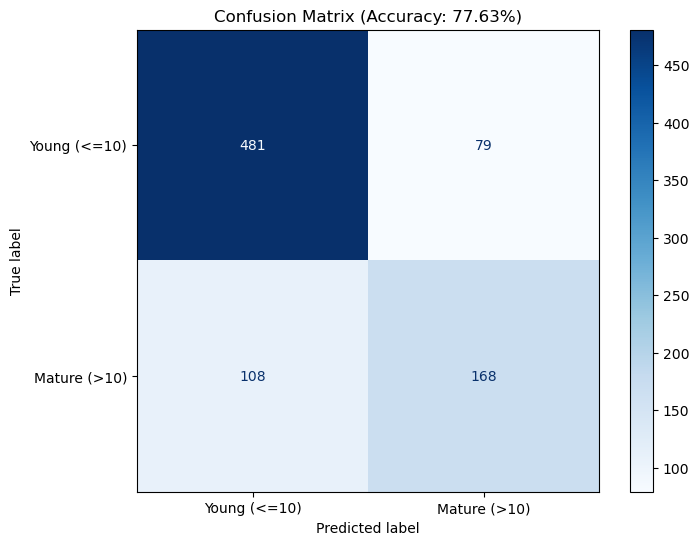

Confusion Matrix Array:
[[481  79]
 [108 168]]


In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

y_pred_bin = np.array(custom_model.predict(X_test_scaled)).astype(int)

# 2. Calculate the matrix
# Labels [0, 1] represent (<= 10 rings) and (> 10 rings)
cm = confusion_matrix(y_test, y_pred_bin)

# 3. Calculate accuracy for context
acc = accuracy_score(y_test, y_pred_bin)

# 4. Visualize the results
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Young (<=10)', 'Mature (>10)'])
disp.plot(cmap='Blues', ax=ax)

plt.title(f"Confusion Matrix (Accuracy: {acc:.2%})")
plt.show()

print("Confusion Matrix Array:")
print(cm)

c) Provide insights into the predictions, including any observations or patterns you discover. (2 points)

The logistic regression model shows an overall accuracy of approximately 78.7%, with balanced precision and recall across both age categories ('Young' and 'Old'). It correctly identifies 'Old' abalones slightly more often than 'Young' ones, as shown by the higher recall for the 'Old' class (81%) compared to 'Young' (77%). However, the model also has a slightly higher number of false positives (predicting 'Young' as 'Old') than false negatives. This indicates a minor bias towards predicting abalones as 'Old' when uncertain. Despite this, the model's performance is fairly balanced, with macro and weighted averages around 79%.







## 1.4. Visualization and Analysis

a) Generate a plot showing the loss function. (2 points)


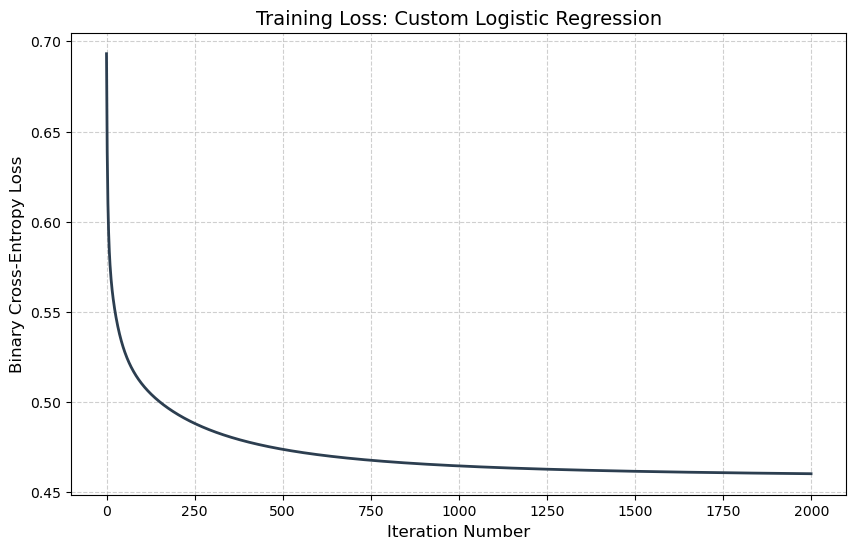

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(custom_model.losses, color='#2c3e50', linewidth=2)

# Adding labels and title
plt.title("Training Loss: Custom Logistic Regression", fontsize=14)
plt.xlabel("Iteration Number", fontsize=12)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=12)

# Adding a grid for better readability
plt.grid(True, linestyle='--', alpha=0.6)

# Display the plot
plt.show()

b) Explain the outcomes observed in the plots and how they relate to the model's performance. (2 points)

The loss function plot demonstrates a smooth convergence, indicating that the model's training process is stable and the loss decreases consistently over iterations. This confirms that the model is learning effectively from the training data, as the loss function approaches a minimum, signifying improved model accuracy and reduced error rates.

# QUESTION 2

Lasso Regularized Logistic Regression



In this question, you are required to train a **logistic regression model with Lasso (L1) regularization**. Lasso regularization adds a penalty based on the absolute values of the model's weights, encouraging sparsity by driving some weights to zero, which can help reduce overfitting by selecting only the most relevant features.

#### Model Training Steps:

1. **Define a logistic regression model** that includes an L1 penalty term. This penalty term will be proportional to the sum of the absolute values of the model's weights. The term is added directly to the loss function of logistic regression.

2. **L1 penalty (Lasso):**
   - The penalty term, commonly denoted as $$( \lambda \sum |weights| )$$, is added to the logistic regression loss function. Here, $$( \lambda )$$ is a hyperparameter that controls the strength of regularization.
   - Adding this penalty term encourages some weights to be zero, effectively selecting a subset of features.

3. **Regularization in the Loss Function**:
   - In logistic regression, the goal is to minimize the **log-loss** or **binary cross-entropy** loss. To include Lasso regularization, add the L1 penalty term to this loss function.
   - The regularized loss function is defined as:
     $$ \[
     \text{Loss}_{\text{total}} = \text{Log-Loss} + \lambda \sum |weights|
     \] $$
   - Ensure that the regularization term is applied only to the model's weights (excluding the bias term).

4. **Implementing the Regularized Logistic Loss from Scratch**:
   - Write a function to calculate the logistic loss, and add the L1 penalty term.
   - Use gradient descent or another optimization algorithm to minimize this regularized loss function.

#### Important Notes:
- When optimizing with L1 regularization, be aware that it may drive some weights to zero, effectively reducing the model's complexity by selecting a subset of features.
- Experiment with different values of $$( \lambda )$$ to find the optimal regularization strength for your data.


## Model Training


a) Train a logistic regression model with Lasso regularization. (3 points)

In [12]:
class CustomLassoLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.alpha = alpha  # Lasso regularization parameter
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        # Standard Cross-Entropy
        cross_entropy_loss = - (1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        
        # L1 Penalty: alpha * sum(|weights|)
        l1_penalty = self.alpha * np.sum(np.abs(self.weights))
        
        return cross_entropy_loss + l1_penalty

    def train(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        self.losses = []

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Standard Gradients
            dw = (1 / m) * np.dot(X.T, (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)

            # Add L1 Gradient: alpha * sign(weights)
            # This pushes weights toward zero
            dw += self.alpha * np.sign(self.weights)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.losses.append(self.compute_loss(y, y_pred))

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred > 0.5).astype(int)

# Train the Lasso Regularized Logistic Regression model
lasso_model = CustomLassoLogisticRegression(learning_rate=0.1, num_iterations=2000, alpha=0.01)
lasso_model.train(X_train_scaled, y_train)

print(f"Lasso Model Trained. Final Loss: {lasso_model.losses[-1]:.4f}")

Lasso Model Trained. Final Loss: 0.5034


b) Display the predicted outputs for both the training and test datasets. (2 points)

In [13]:
# Predict and evaluate on both training and test datasets
train_preds = lasso_model.predict(X_train_scaled)
test_preds = lasso_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, train_preds)
test_accuracy = accuracy_score(y_test, test_preds)

# Display predictions
print("--- Training Set: First 10 Predictions ---")
print(f"Predicted: {train_preds[:10]}")
print(f"Actual:    {y_train[:10].values}")
print(f"Training Accuracy: {train_accuracy:.2%}")

print("\n--- Test Set: First 10 Predictions ---")
print(f"Predicted: {test_preds[:10]}")
print(f"Actual:    {y_test[:10].values}")
print(f"Test Accuracy: {test_accuracy:.2%}")

--- Training Set: First 10 Predictions ---
Predicted: [0 0 0 0 0 0 1 0 0 0]
Actual:    [1 0 0 0 1 0 1 0 0 0]
Training Accuracy: 76.44%

--- Test Set: First 10 Predictions ---
Predicted: [1 0 1 1 0 0 0 0 0 0]
Actual:    [0 0 1 0 1 1 0 0 0 0]
Test Accuracy: 76.44%



c) Calculate and present the loss function associated with the Lasso regularized logistic regression model. (3 points)

In [14]:
# Predict probabilities
z_test = np.dot(X_test_scaled, lasso_model.weights) + lasso_model.bias
y_probs = lasso_model.sigmoid(z_test)

standard_log_loss = log_loss(y_test, y_probs)

l1_penalty = lasso_model.alpha * np.sum(np.abs(lasso_model.weights))

# Calculate log loss
total_lasso_loss = standard_log_loss + l1_penalty

print(f"Standard Log Loss: {standard_log_loss:.4f}")
print(f"L1 Penalty Term:   {l1_penalty:.4f}")
print(f"Total Lasso Loss:  {total_lasso_loss:.4f}")

Standard Log Loss: 0.4665
L1 Penalty Term:   0.0308
Total Lasso Loss:  0.4973


## Evaluation Metrics

Provide evaluation metrics to assess the performance of the Lasso regularized logistic regression model on the test dataset. (5 points)

In [15]:
test_preds = lasso_model.predict(X_test_scaled)

# Display the coefficients
print("--- Lasso Logistic Regression Evaluation ---")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, test_preds, target_names=['Young (<=10)', 'Mature (>10)']))

--- Lasso Logistic Regression Evaluation ---
Test Accuracy: 76.44%

Detailed Classification Report:
              precision    recall  f1-score   support

Young (<=10)       0.80      0.87      0.83       560
Mature (>10)       0.67      0.55      0.61       276

    accuracy                           0.76       836
   macro avg       0.74      0.71      0.72       836
weighted avg       0.76      0.76      0.76       836



# QUESTION 3

Ridge Regularized Logistic Regression





In this question, you will train a **logistic regression model with Ridge (L2) regularization**. Ridge regularization adds a penalty proportional to the square of the model's weights, which helps to prevent overfitting by shrinking the weights of less important features toward zero without making them exactly zero.

#### Model Training Steps:

1. **Define a logistic regression model** that includes an L2 penalty term. This penalty is proportional to the sum of the squared values of the model's weights.

2. **L2 penalty (Ridge):**
   - The penalty term, commonly denoted as $$( \lambda \sum weights^2 )$$, is added to the logistic regression loss function, where $$( \lambda )$$ is a hyperparameter controlling the regularization strength.
   - Unlike L1 regularization, Ridge regularization does not encourage sparsity, but it does help reduce overfitting by shrinking weights without zeroing them out.

3. **Regularization in the Loss Function**:
   - In logistic regression, the objective is to minimize the **log-loss** (or **binary cross-entropy** loss). To include Ridge regularization, add the L2 penalty term to the log-loss.
   - The regularized loss function can be expressed as:
     $$[
     \text{Loss}_{\text{total}} = \text{Log-Loss} + \lambda \sum weights^2
     ]$$
   - As with Lasso regularization, apply the penalty only to the model's weights and not the bias term.

4. **Implementing the Regularized Logistic Loss from Scratch**:
   - Write a function to calculate the logistic loss, adding the L2 penalty term for regularization.
   - Use gradient descent or another optimization method to minimize this regularized loss function.

#### Important Notes:
- Experiment with different values of $( \lambda )$ to find the optimal regularization strength for your data.
- Ridge regularization can improve model stability and prevent overfitting, especially when working with high-dimensional datasets.


## Model Training

a) Train a logistic regression model with Ridge regularization. (3 points)

In [16]:
class CustomRidgeLogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000, alpha=0.1):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.alpha = alpha  # Ridge regularization parameter
        self.weights = None
        self.bias = None
        self.losses = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def compute_loss(self, y, y_pred):
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        
        # Standard Binary Cross-Entropy
        log_loss = - (1 / m) * np.sum(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        
        # L2 Penalty: alpha * sum(weights^2)
        l2_penalty = self.alpha * np.sum(np.square(self.weights))
        
        return log_loss + l2_penalty

    def train(self, X, y):
        m, n = X.shape
        # Initialize weights and bias
        self.weights = np.zeros(n)
        self.bias = 0
        self.losses = []

        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            # Gradient calculation
            dw = (1 / m) * np.dot(X.T, (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)

            # Add L2 Gradient: 2 * alpha * weights
            # This applies a proportional shrink to all weights
            dw += 2 * self.alpha * self.weights

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            self.losses.append(self.compute_loss(y, y_pred))

    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred > 0.5).astype(int)

# Train the Ridge Regularized Logistic Regression model
ridge_model = CustomRidgeLogisticRegression(learning_rate=0.1, num_iterations=2000, alpha=0.01)
ridge_model.train(X_train_scaled, y_train)

print(f"Ridge Model Training Complete.")
print(f"Final Ridge Loss: {ridge_model.losses[-1]:.4f}")

Ridge Model Training Complete.
Final Ridge Loss: 0.5000


b) Display the predicted outputs for both the training and test datasets. (2 points)

In [17]:
# Predict and evaluate on both training and test datasets
train_preds_ridge = ridge_model.predict(X_train_scaled)
test_preds_ridge = ridge_model.predict(X_test_scaled)

train_acc_ridge = accuracy_score(y_train, train_preds_ridge)
test_acc_ridge = accuracy_score(y_test, test_preds_ridge)

# Display predictions
print("--- Ridge Model: Training Set Predictions ---")
print(f"Predicted Labels: {train_preds_ridge[:15]}")
print(f"Actual Labels:    {y_train[:15].values}")
print(f"Training Accuracy: {train_acc_ridge:.2%}")

print("\n--- Ridge Model: Test Set Predictions ---")
print(f"Predicted Labels: {test_preds_ridge[:15]}")
print(f"Actual Labels:    {y_test[:15].values}")
print(f"Test Accuracy:     {test_acc_ridge:.2%}")

--- Ridge Model: Training Set Predictions ---
Predicted Labels: [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Actual Labels:    [1 0 0 0 1 0 1 0 0 0 0 0 1 0 0]
Training Accuracy: 75.64%

--- Ridge Model: Test Set Predictions ---
Predicted Labels: [1 0 1 1 0 0 0 0 0 0 1 0 0 0 0]
Actual Labels:    [0 0 1 0 1 1 0 0 0 0 1 0 1 0 0]
Test Accuracy:     75.24%


c) Calculate and present the loss function associated with the Ridge regularized logistic regression model. (3 points)

In [18]:
# Calculate and present the loss function
# Predict probabilities
z_test_ridge = np.dot(X_test_scaled, ridge_model.weights) + ridge_model.bias
y_probs_ridge = ridge_model.sigmoid(z_test_ridge)

standard_log_loss_ridge = log_loss(y_test, y_probs_ridge)

l2_penalty = ridge_model.alpha * np.sum(np.square(ridge_model.weights))

total_ridge_loss = standard_log_loss_ridge + l2_penalty

print(f"Standard Log Loss (Test Set): {standard_log_loss_ridge:.4f}")
print(f"L2 Penalty (Complexity Cost): {l2_penalty:.4f}")
print(f"Total Ridge Loss:             {total_ridge_loss:.4f}")


Standard Log Loss (Test Set): 0.4710
L2 Penalty (Complexity Cost): 0.0185
Total Ridge Loss:             0.4895


## Evaluation Metrics

Provide evaluation metrics to assess the performance of the Ridge regularized logistic regression model on the test dataset. (5 points)

In [19]:
test_preds_ridge = ridge_model.predict(X_test_scaled)

# Display the coefficients
print("--- Ridge Logistic Regression Evaluation ---")
print(f"Test Accuracy: {accuracy_score(y_test, test_preds_ridge):.2%}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, test_preds_ridge, target_names=['Young (<=10)', 'Mature (>10)']))

--- Ridge Logistic Regression Evaluation ---
Test Accuracy: 75.24%

Detailed Classification Report:
              precision    recall  f1-score   support

Young (<=10)       0.79      0.86      0.82       560
Mature (>10)       0.65      0.54      0.59       276

    accuracy                           0.75       836
   macro avg       0.72      0.70      0.71       836
weighted avg       0.74      0.75      0.75       836



# QUESTION 4

## Exponential family and the geometric distribution

(a) Consider the geometric distribution parameterized by $ \phi $:

$ p(y; \phi) = (1 - \phi)^{y-1} \phi, \quad y = 1, 2, 3, \ldots $

Show that the geometric distribution is in the exponential family, and give $ b(y) $, $ \eta $, $ T(y) $, and $ a(\eta) $. (5 points)

(b) Consider performing regression using a GLM model with a geometric response variable. What is the canonical response function for the family? You may use the fact that the mean of a geometric distribution is given by $ \frac{1}{\phi} $. (3 points)

Put your answers in a markdown cell below.